# Iris Flower Dataset - Exploratory Data Analysis

This project performs Exploratory Data Analysis (EDA) on the Iris Flower Dataset using Python.

Different visualization and statistical techniques are used to understand:
- Feature distributions
- Relationships between features
- Species separability

Libraries used:
- NumPy
- Pandas
- Matplotlib
- Seaborn

In [21]:
# Importing required libraries for data analysis and visualization.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Reading the Iris dataset using pandas.
iris=pd.read_csv('IRIS.csv')

In [23]:
# Checking the number of rows and columns in the dataset.
iris.shape

(150, 5)

In [24]:
# Displaying the feature names (column names) in the dataset
iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [25]:
# Counting the number of datapoints for each species
iris["species"].value_counts()

,count
species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


## Balanced Dataset

The Iris Flower Dataset is a balanced dataset because the number of data points for each flower species is equal.

Each species contains the same number of observations, which helps in building unbiased Machine Learning models.

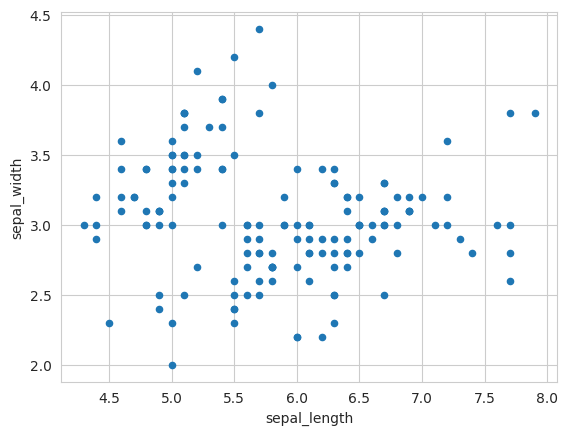

In [26]:
# Scatter plot between sepal length and sepal width
iris.plot(kind="scatter",x='sepal_length',y='sepal_width')
# Used to visualize the relationship between two features
plt.show()

In the above scatter plot, it is difficult to identify which data points belong to which flower species.  
So, we use the Seaborn library to assign different colors to different species using the `hue` parameter.  

This helps in better visualization and understanding of class separation between species.

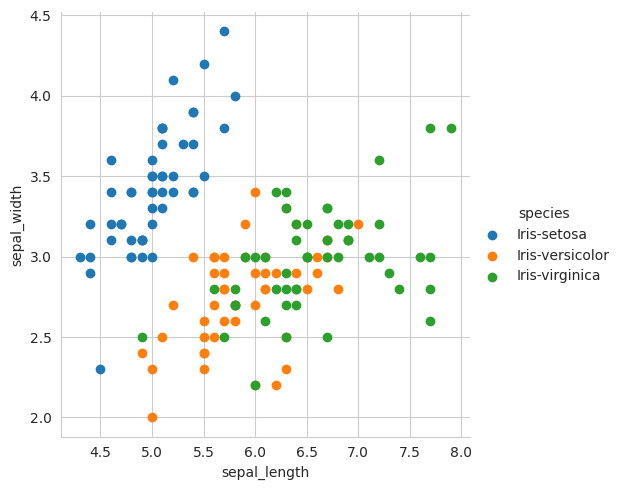

In [27]:
# Using seaborn FacetGrid for colored scatter plotting
# Different colors represent different species
# hue ='species' assigns different colors to different species
sns.set_style("whitegrid")
sns.FacetGrid(iris,hue="species",height=5) \
  .map(plt.scatter,'sepal_length','sepal_width') \
  .add_legend()
plt.show()

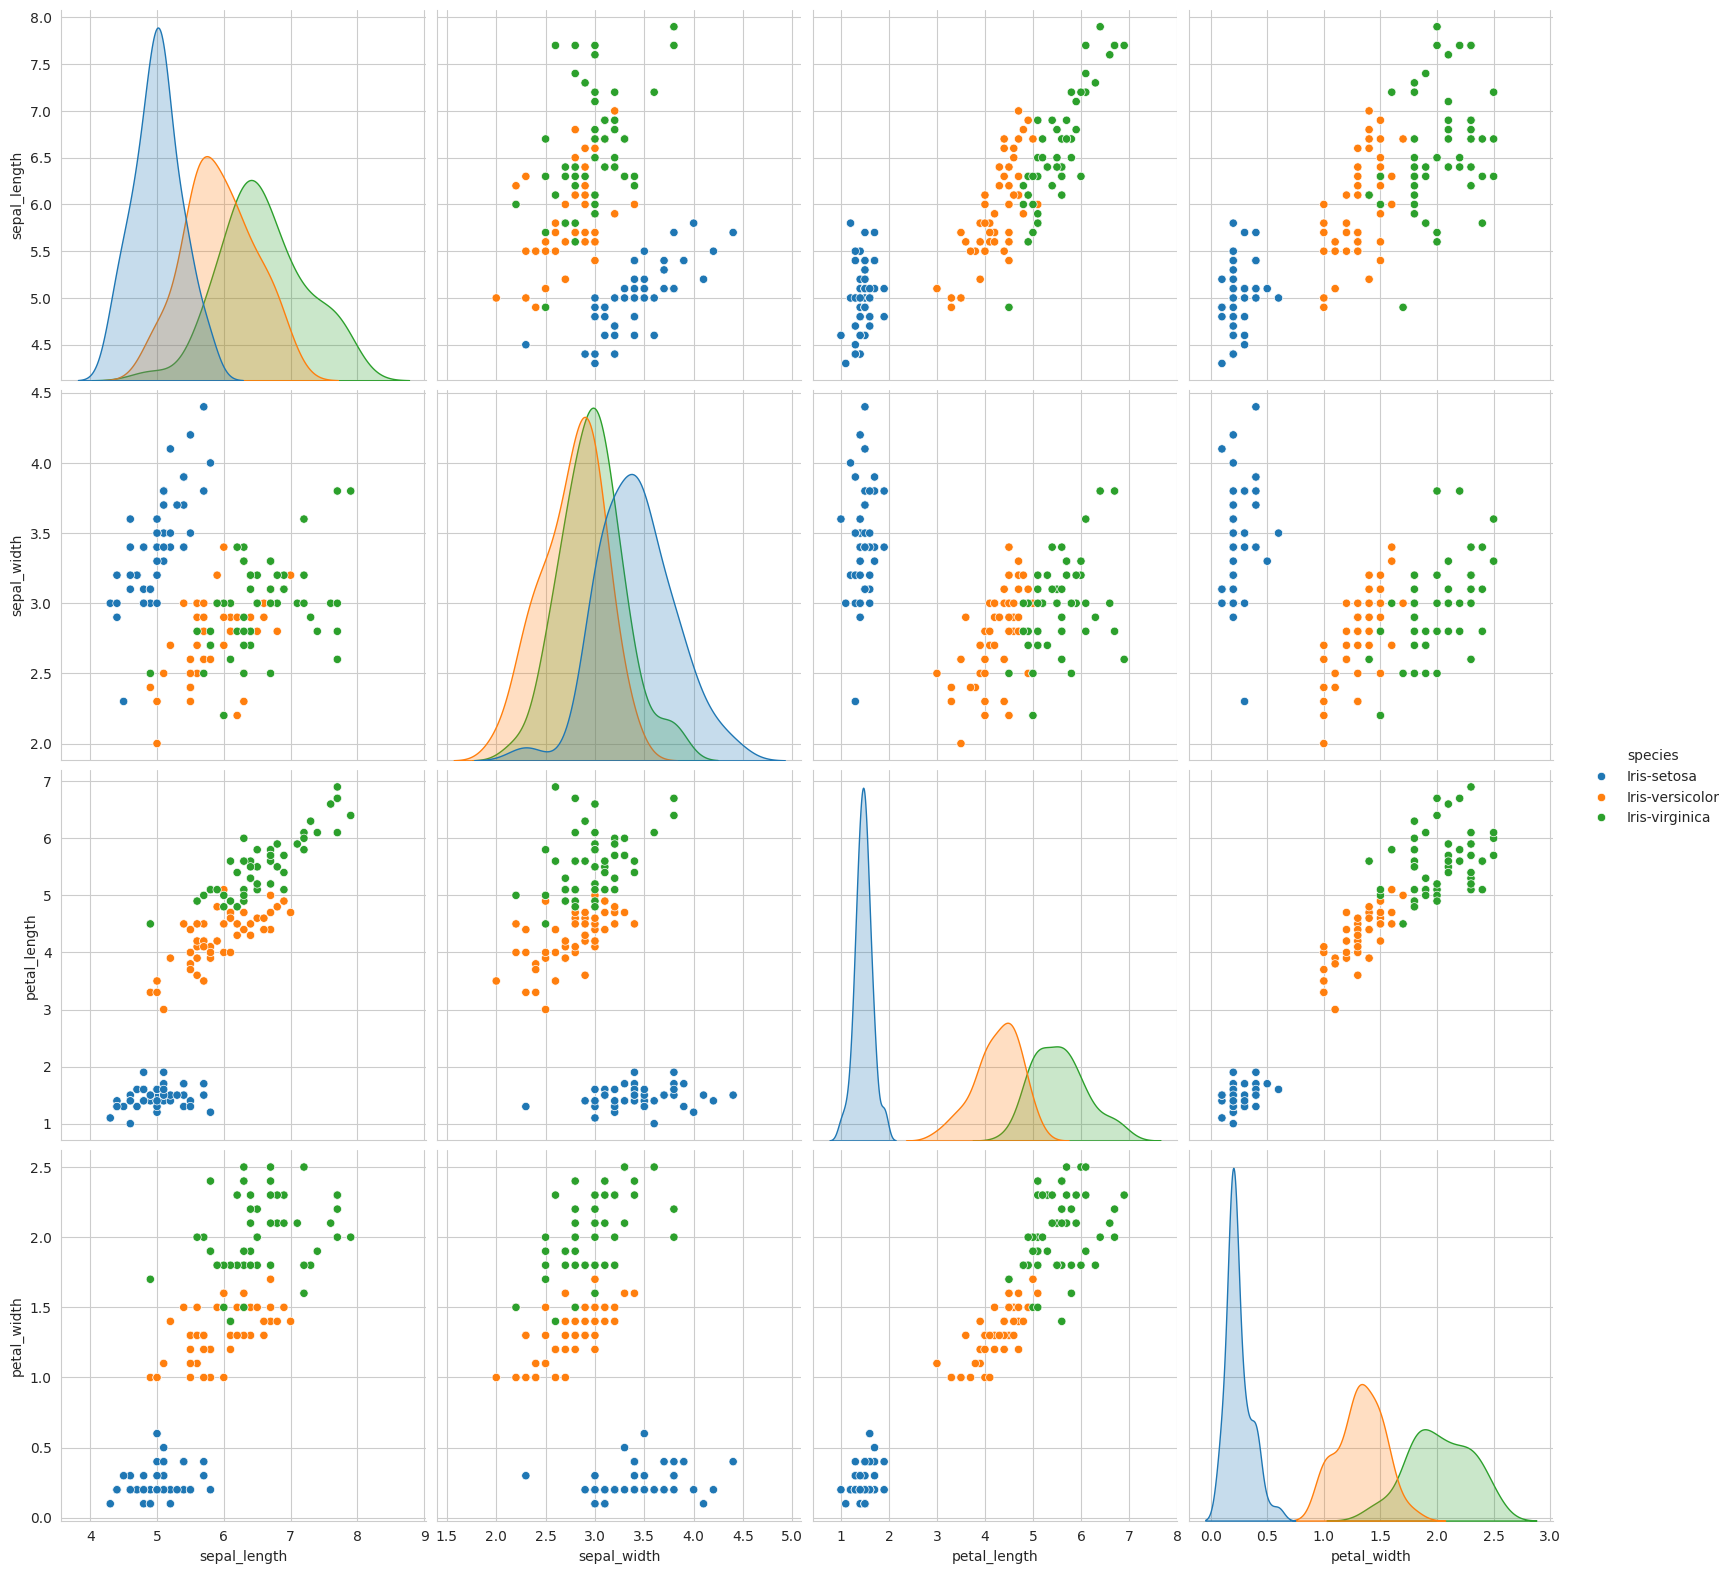

In [28]:
# Pairplots are used for multivariate analysis in EDA(Exploratory data analysis)
# Diagonal plots show feature distributions
# Non-diagonal plots show relationships between feature pairs
sns.set_style("whitegrid")
sns.pairplot(iris,hue="species",height=4)
plt.show()

Plotting a Histogram:

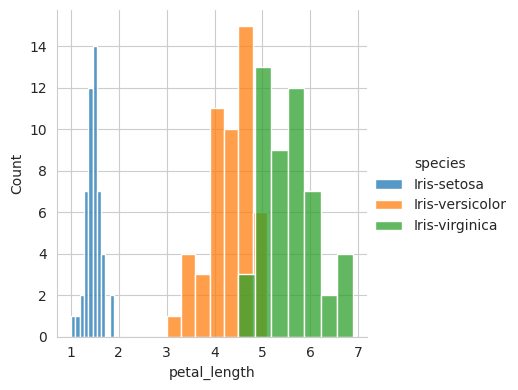

In [29]:
# Histogram of petal length for different flower species
# X-axis represents petal length values
# Y-axis represents the number of data points in each range/bin
sns.FacetGrid(iris,hue="species",height=4) \
  .map(sns.histplot,'petal_length') \
  .add_legend()
plt.show()

Probability Density Function (PDF):

*   It is the smoothed form of histogram
*   It uses Kernel Density Estimation (KDE) for plotting PDF's




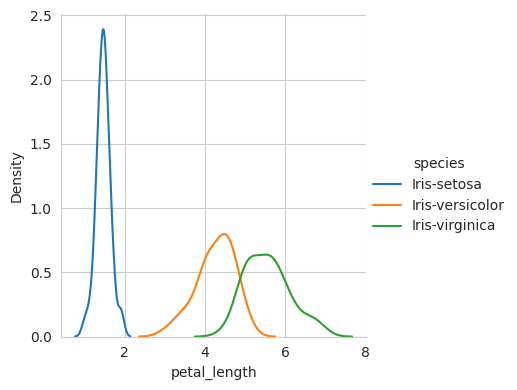

In [30]:
# PDF (Probability Density Function) of petal length
# Shows how data points are distributed across values
sns.FacetGrid(iris,hue='species',height=4) \
  .map(sns.kdeplot,'petal_length') \
  .add_legend()
plt.show()

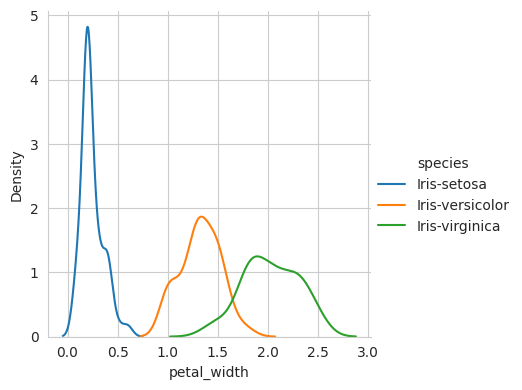

In [31]:
# PDF of petal width
sns.FacetGrid(iris,hue='species',height=4) \
  .map(sns.kdeplot,'petal_width') \
  .add_legend()
plt.show()

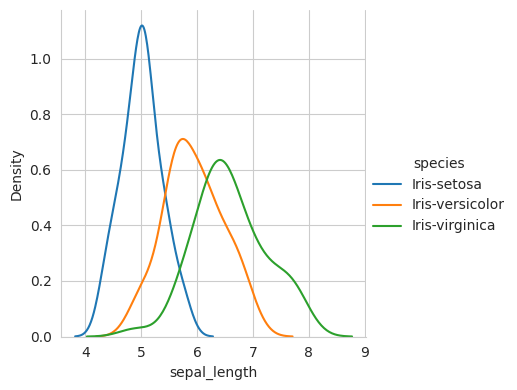

In [32]:
# PDF of sepal length
sns.FacetGrid(iris,hue='species',height=4) \
  .map(sns.kdeplot,'sepal_length') \
  .add_legend()
plt.show()

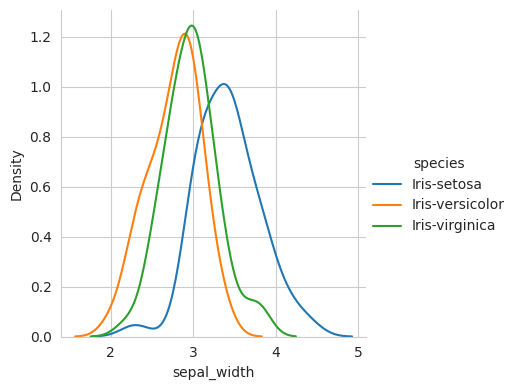

In [33]:
# PDF of sepal width
sns.FacetGrid(iris,hue='species',height=4) \
  .map(sns.kdeplot,'sepal_width') \
  .add_legend()
plt.show()

Univariate Analysis:


*   Among the PDF's of all the features the petal_length is well separated.
*   In the PDF of petal_lengths the setosa flower is linear separable



Cumulative Distribution Function (CDF):


*   It Shows how much percentage of the data lies up to the certain point.
*   The data is divided into bins.



[0.02 0.02 0.04 0.14 0.24 0.28 0.14 0.08 0.   0.04]
[1.   1.09 1.18 1.27 1.36 1.45 1.54 1.63 1.72 1.81 1.9 ]


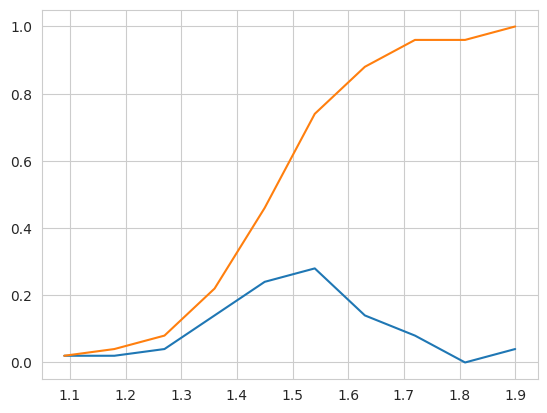

In [34]:
# counts -> number of data points present in each bin
# CDF shows the total probability up to a given value
counts,bin_edges=np.histogram(iris[iris['species'] == 'Iris-setosa']['petal_length'],bins=10,density=True)
pdf=counts/(sum(counts))
# PDF -> probability distribution of data points
print(pdf)
print(bin_edges)
# CDF -> cumulative sum of PDF
cdf=np.cumsum(pdf)
plt.plot(bin_edges[1:],pdf)
plt.plot(bin_edges[1:],cdf)
plt.show()

In [35]:
# Mean represents the average value of the feature
# Mean is sensitive to outliers

print("Means:")
iris_setosa=iris[iris['species']=='Iris-setosa']
iris_versicolor=iris[iris['species']=='Iris-versicolor']
iris_virginica=iris[iris['species']=='Iris-virginica']
print(np.mean(iris_setosa["petal_length"]))
print(np.mean(iris_versicolor['petal_length']))
print(np.mean(iris_virginica['petal_length']))

# Standard deviation measures the spread of the data
# Small standard deviation -> data points are close to the mean
# Large standard deviation -> data points are widely spread
# Std is also sensitive for Outliers
print("\nStd-Dev")
print(np.std(iris_setosa['petal_length']))
print(np.std(iris_versicolor['petal_length']))
print(np.std(iris_virginica['petal_length']))


Means:
1.464
4.26
5.5520000000000005

Std-Dev
0.17176728442867115
0.4651881339845204
0.5463478745268441


In [36]:
iris_setosa=iris[iris['species']=='Iris-setosa']
iris_versicolor=iris[iris['species']=='Iris-versicolor']
iris_virginica=iris[iris['species']=='Iris-virginica']

# Median represents the middle value of the dataset
# Median is less affected by outliers
print("Medians:")
print(np.median(iris_setosa['petal_length']))
print(np.median(iris_versicolor['petal_length']))
print(np.median(iris_virginica['petal_length']))

# Percentiles and Quartiles indicate the percentage of data below a given value
print('\nPercentiles:')
print(np.percentile(iris_setosa['petal_length'],90))
print(np.percentile(iris_versicolor['petal_length'],90))
print(np.percentile(iris_virginica['petal_length'],90))

print('\nQuartiles:')
print(np.percentile(iris_setosa['petal_length'],np.arange(0,100,25)))
print(np.percentile(iris_versicolor['petal_length'],np.arange(0,100,25)))
print(np.percentile(iris_virginica['petal_length'],np.arange(0,100,25)))

from statsmodels import robust
print('\nMedian Absolute Deviation:')
print(robust.mad(iris_setosa['petal_length']))
print(robust.mad(iris_versicolor['petal_length']))
print(robust.mad(iris_virginica['petal_length']))

Medians:
1.5
4.35
5.55

Percentiles:
1.7
4.8
6.31

Quartiles:
[1.    1.4   1.5   1.575]
[3.   4.   4.35 4.6 ]
[4.5   5.1   5.55  5.875]

Median Absolute Deviation:
0.14826022185056031
0.5189107764769602
0.6671709983275211


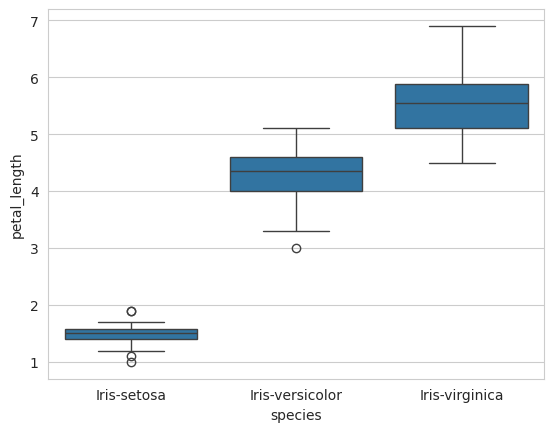

In [37]:
# Box plot shows median, quartiles, and outliers
# Useful for understanding data spread and detecting outliers
sns.boxplot(x='species',y='petal_length',data=iris)
plt.show()

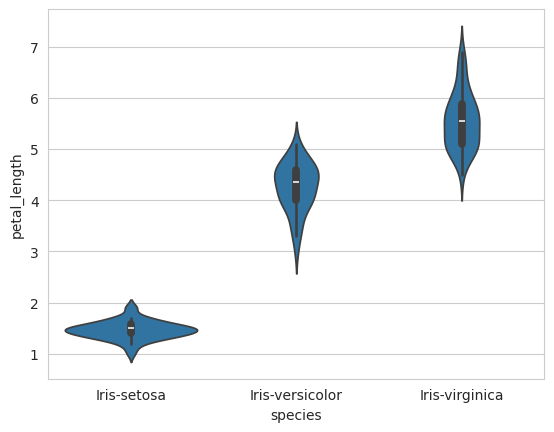

In [38]:
# Violin plot combines box plot and PDF
# Shows both distribution and density of the data
sns.violinplot(x='species',y='petal_length',data=iris)
plt.show()

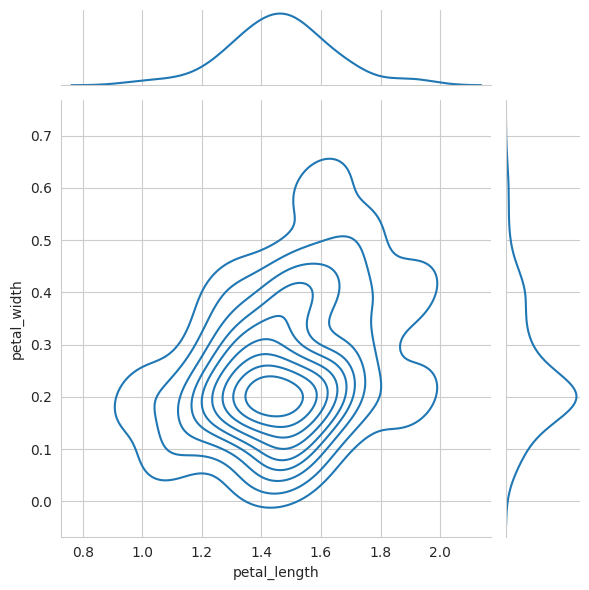

In [39]:
# Joint plot shows both scatter plot and distribution together
# Useful for understanding relationships between two features
sns.jointplot(x='petal_length',y='petal_width',data=iris_setosa,kind='kde')
plt.show()

# Conclusion

## Observations

- Petal length and petal width are very useful for class separation.
- Iris-setosa is easily separable from the other species.
- Some overlap exists between Iris-versicolor and Iris-virginica.
- Pair plots and scatter plots help visualize feature relationships effectively.
- Statistical measures such as mean, median, and standard deviation help summarize the dataset.
- PDF and CDF provide insights into feature distributions.

## Final Outcome
EDA helped in understanding the dataset before applying Machine Learning models.